<div style="background:#123B63;color:white;padding:14px 18px;border-radius:6px">
<b>CSE 816 &mdash; Machine Learning Lab</b> &nbsp;&middot;&nbsp; Department of CSE, University of Chittagong<br>
<span style="font-size:90%">Module 1 &middot; Week 3 &middot; Part 1 of 4 &nbsp;&middot;&nbsp; 60 minutes</span>
</div>

# Classification and the Sigmoid

Weeks 1 and 2 predicted a *number*: the price of a flat. This week the target is a
*category* &mdash; will this loan be repaid, is this tumour malignant, is this transaction
fraudulent. That sounds like a small change. It is not: the model, the cost function and the
way you read the output all have to be rebuilt.

This part rebuilds the **model**. Part 2 rebuilds the **cost**, Part 3 puts them together,
and Part 4 deals with the trouble that flexibility causes.

**Companion theory lecture:** CSE 815, Week 3, Part 1 (Classification and Logistic Regression).

## What you will be able to do

1. Show, with numbers, why fitting a straight line to a 0/1 target and rounding is not a
   classifier.
2. Implement the sigmoid function so that it does not overflow, and verify its four defining
   properties.
3. Derive and check $g'(z) = g(z)(1-g(z))$ against a finite-difference estimate.
4. Read a logistic model's output as a probability, and convert between probability, odds and
   log-odds.
5. Locate the decision boundary of a one-feature model and predict a label from it.

---

## 1. Setup

Two data sets this week.

**`load_loans()`** is the running data set for Week 3: 120 microfinance borrowers in
Chattogram, each described by monthly income (thousand BDT) and existing debt service as a
percentage of that income. The label is `1` if the loan was repaid in full and `0` if it
defaulted.

**`load_screening()`** is eight patients &mdash; tumour diameter in centimetres against a
malignant/benign label. It is small enough to work through by hand, which is what makes it
useful for seeing an algorithm rather than merely running one. (Part 3 also reproduces the
four-point trace the lecture works through on the board; that is a different, even smaller
set.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

np.set_printoptions(precision=4, suppress=True)

BLUE, TEAL, AMBER, ROSE, GRAY = "#123B63", "#1B7F79", "#C97B17", "#9B2C4B", "#4A5560"


def load_loans(seed=816, m=120):
    """Chattogram microfinance borrowers. Returns X (income, debt%) and y (1 = repaid)."""
    rng = np.random.default_rng(seed)
    income = np.round(rng.uniform(12, 90, m), 1)      # thousand BDT per month
    debt = np.round(rng.uniform(2, 58, m), 1)         # per cent of income
    z = 0.105 * (income - 42.0) - 0.125 * (debt - 28.0)
    y = (rng.random(m) < 1.0 / (1.0 + np.exp(-z))).astype(float)
    return np.column_stack([income, debt]), y


def load_screening():
    """Eight patients: tumour diameter (cm), 1 = malignant. Small enough to work
    through by hand, and deliberately not separable -- the 2 cm tumour was malignant
    and the 5 cm one was not."""
    return np.arange(1.0, 9.0).reshape(-1, 1), np.array([0., 1, 0, 0, 0, 1, 1, 1])


X_loan, y_loan = load_loans()
print("X_loan.shape:", X_loan.shape, "  y_loan.shape:", y_loan.shape)
print(f"repaid: {int(y_loan.sum())} of {len(y_loan)}  ({y_loan.mean():.1%})")
print(f"\n{'income':>8} {'debt %':>8} {'repaid':>8}")
print("-" * 27)
for i in range(6):
    print(f"{X_loan[i, 0]:8.1f} {X_loan[i, 1]:8.1f} {y_loan[i]:8.0f}")

X_loan.shape: (120, 2)   y_loan.shape: (120,)
repaid: 63 of 120  (52.5%)

  income   debt %   repaid
---------------------------
    67.4     41.9        1
    52.0     33.7        0
    45.4     33.7        1
    51.4     32.6        1
    57.1      3.9        1
    28.9      8.5        1


distinct values of y: [0. 1.]


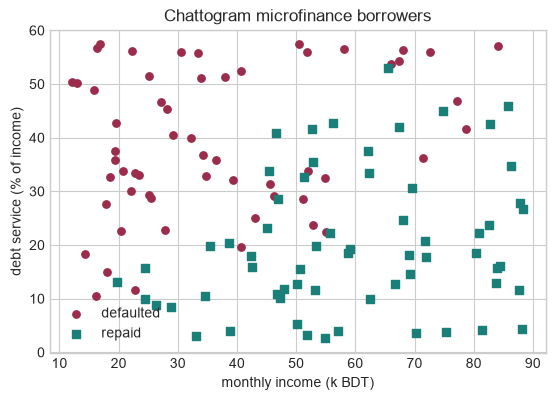

In [2]:
# The label takes exactly two values. That is the whole difficulty.
print("distinct values of y:", np.unique(y_loan))

fig, ax = plt.subplots(figsize=(6.4, 4.2))
for label, colour, marker, name in [(0.0, ROSE, "o", "defaulted"), (1.0, TEAL, "s", "repaid")]:
    sel = y_loan == label
    ax.scatter(X_loan[sel, 0], X_loan[sel, 1], c=colour, marker=marker, s=28, label=name)
ax.set_xlabel("monthly income (k BDT)")
ax.set_ylabel("debt service (% of income)")
ax.set_title("Chattogram microfinance borrowers")
ax.legend()
plt.show()

The two classes overlap. No straight line separates them, and no model built this week will
get every label right &mdash; which is realistic, and is the reason Part 3 spends time on how
to *measure* a classifier rather than just fitting one.

---

## 2. Why not just fit a line and round?

The obvious first attempt: the label is a number, `0` or `1`, so fit a straight line by least
squares as in Week 1 and predict `1` whenever the line is above `0.5`.

We test this on the eight-patient screening set, because it is small enough to see everything
at once.

In [3]:
X_scr, y_scr = load_screening()
x_scr = X_scr[:, 0]


def fit_least_squares(x, y):
    """Ordinary least squares for a single feature. Returns (w, b)."""
    A = np.column_stack([x, np.ones(len(x))])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return float(coef[0]), float(coef[1])


w_ls, b_ls = fit_least_squares(x_scr, y_scr)
fitted = w_ls * x_scr + b_ls

print(f"least squares:  w = {w_ls:.6f}   b = {b_ls:.6f}")
print(f"crosses 0.5 at x = {(0.5 - b_ls) / w_ls:.4f} cm")
print(f"\n{'x (cm)':>7} {'y':>4} {'f(x)':>9}")
print("-" * 22)
for xi, yi, fi in zip(x_scr, y_scr, fitted):
    print(f"{xi:7.0f} {yi:4.0f} {fi:9.4f}")

least squares:  w = 0.119048   b = -0.035714
crosses 0.5 at x = 4.5000 cm

 x (cm)    y      f(x)
----------------------
      1    0    0.0833
      2    1    0.2024
      3    0    0.3214
      4    0    0.4405
      5    0    0.5595
      6    1    0.6786
      7    1    0.7976
      8    1    0.9167


### Failure 1: the output is not a probability, or anything else

On the training points the fitted values happen to lie inside $[0,1]$. Step outside the range
of the data and they do not.

In [4]:
for xi in [0.0, 12.0, 25.0]:
    print(f"  f({xi:5.1f} cm) = {w_ls * xi + b_ls:8.4f}")

print("\nA tumour of zero size is -3.6% malignant and one of 25 cm is 294% malignant.")
print("There is no reading of the output under which those are answers.")

assert w_ls * 25.0 + b_ls > 1.0, "the straight line should leave [0, 1]"
assert w_ls * 0.0 + b_ls < 0.0

  f(  0.0 cm) =  -0.0357
  f( 12.0 cm) =   1.3929
  f( 25.0 cm) =   2.9405

A tumour of zero size is -3.6% malignant and one of 25 cm is 294% malignant.
There is no reading of the output under which those are answers.


### Failure 2: the fit is driven by distance, not by correctness

Least squares minimises squared *distance* to the targets. An example far out along the
$x$-axis, correctly classified and never in doubt, still has a large residual if the line does
not pass close to it &mdash; so the fit bends to reduce it.

Add one more malignant tumour, of a size no method could get wrong, and watch the threshold
crossing walk away.

In [5]:
print(f"{'extra example':>15} {'w':>10} {'b':>10} {'crosses 0.5 at':>15}")
print("-" * 54)
print(f"{'none':>15} {w_ls:10.6f} {b_ls:10.6f} {(0.5 - b_ls) / w_ls:15.4f}")

for extra in [10.0, 20.0, 50.0, 100.0]:
    w_e, b_e = fit_least_squares(np.r_[x_scr, extra], np.r_[y_scr, 1.0])
    print(f"{'x = ' + str(int(extra)):>15} {w_e:10.6f} {b_e:10.6f} {(0.5 - b_e) / w_e:15.4f}")

print("\nThe boundary moved from 4.50 cm to 5.57 cm because of a 100 cm tumour")
print("about which there was never the slightest doubt.")

  extra example          w          b  crosses 0.5 at
------------------------------------------------------
           none   0.119048  -0.035714          4.5000
         x = 10   0.108065   0.003226          4.5970
         x = 20   0.046522   0.266087          5.0280
         x = 50   0.013400   0.427509          5.4097
        x = 100   0.005822   0.467576          5.5691

The boundary moved from 4.50 cm to 5.57 cm because of a 100 cm tumour
about which there was never the slightest doubt.


> **The two requirements.** A classifier needs (a) a model whose output is confined to
> $[0,1]$, and (b) a cost that charges for being **wrong** rather than for being **far**.
> Least squares fails both. The rest of this part fixes (a); Part 2 fixes (b).

---

## 3. The sigmoid function

Keep the linear part $z = \mathbf{w}\cdot\mathbf{x} + b$ &mdash; it carries all the parameters
&mdash; and pass it through a function that squashes $\mathbb{R}$ onto $(0,1)$:

$$g(z) = \frac{1}{1 + e^{-z}}$$

A naive implementation overflows. `np.exp` returns `inf` for arguments above about 709, so
`np.exp(-z)` blows up for large **negative** `z`. The overflow is silent apart from a warning,
and it poisons everything downstream.

In [6]:
def sigmoid_naive(z):
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid(z):
    """Numerically stable sigmoid: algebraically identical, but never exponentiates a
    large positive number."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))       # -z <= 0, so exp is at most 1
    ez = np.exp(z[~pos])                            # z < 0, so exp is at most 1
    out[~pos] = ez / (1.0 + ez)
    return out[()] if out.ndim == 0 else out


probe = np.array([-800.0, -40.0, 0.0, 40.0])

try:
    with np.errstate(over="raise"):
        naive = sigmoid_naive(probe)
    print("naive :", naive)
except FloatingPointError as exc:
    print("naive : FloatingPointError --", exc)
    with np.errstate(over="ignore"):
        print("        (with the warning silenced it returns", sigmoid_naive(probe), ")")

print("stable:", sigmoid(probe))
print("\nBoth reach the same answers where the naive one survives at all; only the")
print("stable version gets there without ever exponentiating a large positive number.")

assert np.all(np.isfinite(sigmoid(probe)))

naive : FloatingPointError -- overflow encountered in exp
        (with the warning silenced it returns [0.  0.  0.5 1. ] )
stable: [0.  0.  0.5 1. ]

Both reach the same answers where the naive one survives at all; only the
stable version gets there without ever exponentiating a large positive number.


### The four properties

Everything the sigmoid is used for follows from these. Check each rather than memorising it.

In [7]:
z = np.linspace(-8, 8, 401)
g = sigmoid(z)

# 1. Range: strictly inside (0, 1).
assert np.all((g > 0) & (g < 1))

# 2. Centre: g(0) = 1/2.
assert np.isclose(sigmoid(0.0), 0.5)

# 3. Symmetry: 1 - g(z) = g(-z).
assert np.allclose(1 - sigmoid(z), sigmoid(-z))

# 4. Monotonicity: strictly increasing.
assert np.all(np.diff(g) > 0)

print("range       : min %.6f  max %.6f" % (g.min(), g.max()))
print("centre      : g(0) = %.6f" % sigmoid(0.0))
print("symmetry    : max |1 - g(z) - g(-z)| = %.2e" % np.abs(1 - sigmoid(z) - sigmoid(-z)).max())
print("monotonicity: smallest step = %.2e (positive everywhere)" % np.diff(g).min())
print("\nAll four properties verified.")

range       : min 0.000335  max 0.999665
centre      : g(0) = 0.500000
symmetry    : max |1 - g(z) - g(-z)| = 1.53e-16
monotonicity: smallest step = 1.37e-05 (positive everywhere)

All four properties verified.


Property 1 is a statement about real numbers, and `float64` is not the real numbers. Find
where the arithmetic gives up &mdash; you will need the answer in Part 2, where the cost takes
the logarithm of this output.

In [8]:
print(f"{'z':>8} {'g(z)':>26} {'strictly inside (0,1)?':>24}")
print("-" * 62)
for zi in [-800.0, -745.0, -40.0, 0.0, 36.0, 37.0, 800.0]:
    v = float(sigmoid(np.array(zi)))
    print(f"{zi:8.1f} {v!r:>26} {str(0.0 < v < 1.0):>24}")

print("\nIn exact arithmetic 0 < g(z) < 1 always. In float64 the result rounds to 1.0 at")
print("about z = 37 and underflows to 0.0 below about z = -745.")
print("So `np.log(f)` and `np.log(1 - f)` can both produce -inf, and Part 2's cost")
print("function has to defend against it.")

# True on the range where the arithmetic is faithful, which is every z you will meet
# once the features are scaled.
safe = np.linspace(-36, 36, 2001)
assert np.all((sigmoid(safe) > 0) & (sigmoid(safe) < 1))

       z                       g(z)   strictly inside (0,1)?
--------------------------------------------------------------
  -800.0                        0.0                    False
  -745.0                     5e-324                     True
   -40.0      4.248354255291589e-18                     True
     0.0                        0.5                     True
    36.0         0.9999999999999998                     True
    37.0                        1.0                    False
   800.0                        1.0                    False

In exact arithmetic 0 < g(z) < 1 always. In float64 the result rounds to 1.0 at
about z = 37 and underflows to 0.0 below about z = -745.
So `np.log(f)` and `np.log(1 - f)` can both produce -inf, and Part 2's cost
function has to defend against it.


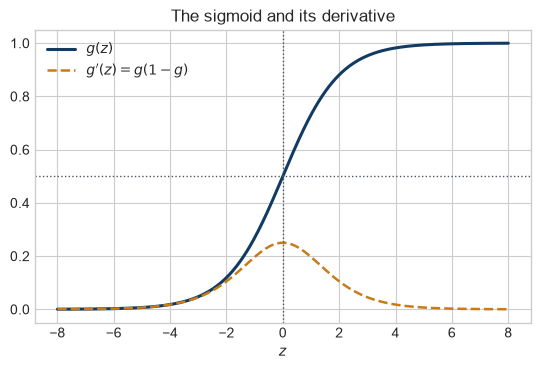

Beyond |z| = 4 the slope is under 0.0177: the model is not merely confident there,
it is nearly unresponsive. Part 2 shows why that matters for the choice of cost.


In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(z, g, c=BLUE, lw=2.2, label="$g(z)$")
ax.plot(z, g * (1 - g), c=AMBER, lw=1.8, ls="--", label="$g'(z) = g(1-g)$")
ax.axhline(0.5, c=GRAY, lw=1.0, ls=":")
ax.axvline(0.0, c=GRAY, lw=1.0, ls=":")
ax.set_xlabel("$z$")
ax.set_title("The sigmoid and its derivative")
ax.legend()
plt.show()

print("Beyond |z| = 4 the slope is under %.4f: the model is not merely confident there,"
      % float(sigmoid(4.0) * (1 - sigmoid(4.0))))
print("it is nearly unresponsive. Part 2 shows why that matters for the choice of cost.")

---

## 4. The derivative

The identity you will use for the rest of the course:

$$g'(z) = g(z)\bigl(1 - g(z)\bigr)$$

Derived on the board; verified here against a central finite difference, which is the check
you should run on **any** derivative you write.

In [10]:
def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)


def finite_difference(f, z, h=1e-6):
    """Central difference: accurate to O(h^2), and good enough to catch a wrong formula."""
    return (f(z + h) - f(z - h)) / (2 * h)


probe = np.array([-6.0, -2.0, -0.5, 0.0, 0.5, 2.0, 6.0])
analytic = sigmoid_prime(probe)
numeric = finite_difference(sigmoid, probe)

print(f"{'z':>6} {'analytic':>12} {'finite diff':>13} {'|difference|':>14}")
print("-" * 48)
for zi, a, n in zip(probe, analytic, numeric):
    print(f"{zi:6.1f} {a:12.8f} {n:13.8f} {abs(a - n):14.2e}")

assert np.allclose(analytic, numeric, atol=1e-8)
print("\nThe formula agrees with the numerical derivative everywhere tested.")
print(f"Maximum slope: {sigmoid_prime(0.0):.4f} at z = 0, exactly 1/4.")

assert np.isclose(sigmoid_prime(0.0), 0.25)
assert sigmoid_prime(0.0) >= sigmoid_prime(probe).max()

     z     analytic   finite diff   |difference|
------------------------------------------------
  -6.0   0.00246651    0.00246651       5.88e-13
  -2.0   0.10499359    0.10499359       1.28e-12
  -0.5   0.23500371    0.23500371       3.85e-11
   0.0   0.25000000    0.25000000       7.19e-12
   0.5   0.23500371    0.23500371       1.07e-11
   2.0   0.10499359    0.10499359       2.21e-11
   6.0   0.00246651    0.00246651       7.23e-11

The formula agrees with the numerical derivative everywhere tested.
Maximum slope: 0.2500 at z = 0, exactly 1/4.


### Checkpoint 1

The sigmoid's derivative peaks at $z = 0$ and decays in both tails. Write
`half_life(target)` that returns the smallest $|z|$ at which $g'(z)$ has fallen to `target`
times its maximum value of $0.25$. Solve it by a search over a fine grid of $z$, not
algebraically.

Report the answer for `target = 0.5` and for `target = 0.01`.

*Expected:* about `1.7628` and `5.9865`. (Check the first against the algebra: $g' = 0.125$
means $g(1-g) = 0.125$, so $g = (1 \pm 1/\sqrt{2})/2$.)

In [11]:
# Your code here

---

## 5. The logistic model, and what its output means

$$f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w}\cdot\mathbf{x} + b)
  = \frac{1}{1 + e^{-(\mathbf{w}\cdot\mathbf{x} + b)}}$$

The parameters are the same $\mathbf{w}$ and $b$ as in Week 2. Only the last step is new.

The model's **assumption** &mdash; and it is an assumption, not a theorem &mdash; is that this
number is a probability:

$$\mathbb{P}(y = 1 \mid \mathbf{x}) = f_{\mathbf{w},b}(\mathbf{x}), \qquad
  \mathbb{P}(y = 0 \mid \mathbf{x}) = 1 - f_{\mathbf{w},b}(\mathbf{x})$$

Part 3 fits the parameters. For now, take the fitted values from the lecture and read them.

In [12]:
def predict_proba(X, w, b):
    """P(y = 1 | x) for every row of X."""
    return sigmoid(X @ w + b)


# The converged fit on this set. Part 3 gives you the algorithm that produces it;
# exercise 1 of Part 3 asks you to reproduce these two numbers yourself.
w_scr, b_scr = np.array([0.594084]), -2.673380

p_scr = predict_proba(X_scr, w_scr, b_scr)

print(f"{'x (cm)':>7} {'y':>4} {'P(malignant)':>14}")
print("-" * 28)
for xi, yi, pi in zip(x_scr, y_scr, p_scr):
    print(f"{xi:7.0f} {yi:4.0f} {pi:14.4f}")

print("\nJ is at its minimum here; Part 3 supplies the algorithm that found it.")
assert np.all((p_scr > 0) & (p_scr < 1))

 x (cm)    y   P(malignant)
----------------------------
      1    0         0.1111
      2    1         0.1846
      3    0         0.2909
      4    0         0.4263
      5    0         0.5737
      6    1         0.7091
      7    1         0.8154
      8    1         0.8889

J is at its minimum here; Part 3 supplies the algorithm that found it.


### Odds, log-odds, and what a coefficient means

Invert the sigmoid. Writing $p = g(z)$ and solving for $z$:

$$p(1 + e^{-z}) = 1 \;\Longrightarrow\; e^{-z} = \frac{1-p}{p}
  \;\Longrightarrow\; z = \ln\!\left(\frac{p}{1-p}\right)$$

$p/(1-p)$ is the **odds**; its logarithm is the **log-odds**, or **logit**. So the model says

$$\ln \frac{\mathbb{P}(y=1\mid\mathbf{x})}{\mathbb{P}(y=0\mid\mathbf{x})} = \mathbf{w}\cdot\mathbf{x} + b$$

Logistic regression is an exactly *linear* model &mdash; of the log-odds. That is what makes
a coefficient readable: adding 1 to $x_j$ adds $w_j$ to the log-odds, and therefore
**multiplies the odds by $e^{w_j}$**.

In [13]:
def logit(p):
    return np.log(p / (1 - p))


# The round trip must be exact.
p_probe = np.array([0.01, 0.25, 0.5, 0.75, 0.99])
assert np.allclose(sigmoid(logit(p_probe)), p_probe)
print("logit and sigmoid invert each other:", np.allclose(sigmoid(logit(p_probe)), p_probe))

# And the model's z really is the log-odds of its own output.
z_scr = X_scr @ w_scr + b_scr
assert np.allclose(logit(p_scr), z_scr)

print(f"\n{'x (cm)':>7} {'P':>9} {'odds':>9} {'log-odds':>10} {'w*x+b':>9}")
print("-" * 48)
for xi, pi, zi in zip(x_scr, p_scr, z_scr):
    print(f"{xi:7.0f} {pi:9.4f} {pi / (1 - pi):9.4f} {logit(pi):10.4f} {zi:9.4f}")

print(f"\nEach extra centimetre multiplies the odds by e^w = {np.exp(w_scr[0]):.4f}.")
print("Check it directly: the ratio of consecutive odds is constant.")
odds = p_scr / (1 - p_scr)
print("  odds ratios:", np.round(odds[1:] / odds[:-1], 6))
assert np.allclose(odds[1:] / odds[:-1], np.exp(w_scr[0]))

logit and sigmoid invert each other: True

 x (cm)         P      odds   log-odds     w*x+b
------------------------------------------------
      1    0.1111    0.1250    -2.0793   -2.0793
      2    0.1846    0.2265    -1.4852   -1.4852
      3    0.2909    0.4102    -0.8911   -0.8911
      4    0.4263    0.7430    -0.2970   -0.2970
      5    0.5737    1.3459     0.2970    0.2970
      6    0.7091    2.4379     0.8911    0.8911
      7    0.8154    4.4159     1.4852    1.4852
      8    0.8889    7.9988     2.0793    2.0793

Each extra centimetre multiplies the odds by e^w = 1.8114.
Check it directly: the ratio of consecutive odds is constant.
  odds ratios: [1.8114 1.8114 1.8114 1.8114 1.8114 1.8114 1.8114]


> **Careful.** The effect on the *odds* is constant; the effect on the *probability* is not.
> Going from 1 cm to 2 cm raises $P$ by 0.074; going from 4 cm to 5 cm raises it by 0.147, twice
> as much. The sigmoid is steepest in the middle, and a coefficient quoted as "each centimetre
> adds so many percentage points" is wrong wherever it is quoted.

---

## 6. The decision boundary

A probability is not a decision. To classify, compare it with a threshold &mdash; take $0.5$
for now, and Part 3 will show why that default deserves an argument.

Because $g$ is increasing and $g(0) = \tfrac12$,

$$f_{\mathbf{w},b}(\mathbf{x}) \ge \tfrac12
  \iff \mathbf{w}\cdot\mathbf{x} + b \ge 0$$

The sigmoid drops out of the decision entirely. With one feature the boundary is the single
point $x^\star = -b/w$.

In [14]:
x_star = -b_scr / w_scr[0]
print(f"decision boundary: x* = -b/w = {x_star:.4f} cm")

pred = (p_scr >= 0.5).astype(float)
print(f"\n{'x (cm)':>7} {'y':>4} {'P':>9} {'predicted':>10}")
print("-" * 34)
for xi, yi, pi, pr in zip(x_scr, y_scr, p_scr, pred):
    print(f"{xi:7.0f} {yi:4.0f} {pi:9.4f} {pr:10.0f}")

print(f"\naccuracy: {(pred == y_scr).mean():.4f}  ({int((pred == y_scr).sum())} of {len(y_scr)})")

# The two rules must agree: thresholding P at 0.5 is thresholding z at 0.
assert np.array_equal(p_scr >= 0.5, z_scr >= 0)
print("\nThresholding P at 0.5 and thresholding w.x + b at 0 give identical decisions.")

decision boundary: x* = -b/w = 4.5000 cm

 x (cm)    y         P  predicted
----------------------------------
      1    0    0.1111          0
      2    1    0.1846          0
      3    0    0.2909          0
      4    0    0.4263          0
      5    0    0.5737          1
      6    1    0.7091          1
      7    1    0.8154          1
      8    1    0.8889          1

accuracy: 0.7500  (6 of 8)

Thresholding P at 0.5 and thresholding w.x + b at 0 give identical decisions.


Two of the eight are wrong, and they are the two that broke the pattern: the malignant 2 cm
tumour (rated 0.1846) and the benign 5 cm one (rated 0.5737). Both are close calls in the
model's own terms. Part 3 shows that moving the threshold repairs the second for nothing and
the first only at a price.

### Checkpoint 2

A colleague fits a logistic model to the loans data using **income alone** and reports
`w = 0.056962`, `b = -2.610526`.

1. Write `describe(w, b)` that prints the decision boundary in thousand BDT, and the factor by
   which the odds of repayment multiply for each extra 10 thousand BDT of monthly income.
2. Use `predict_proba` to find the model's probability for an applicant earning 30 k BDT, and
   for one earning 60 k BDT.

*Expected:* boundary at about `45.83` k BDT; each extra 10 k multiplies the odds by about
`1.7676`; the two probabilities are about `0.2887` and `0.6915`.

In [ ]:
# Your code here

---

## 7. Recap

- A category is not a number. Fitting a line to a 0/1 target fails twice over: the output
  leaves $[0,1]$, and the fit is dragged around by correctly-classified examples that happen to
  be far away.
- $g(z) = 1/(1+e^{-z})$ maps $\mathbb{R}$ onto $(0,1)$, passes through $(0,\tfrac12)$, satisfies
  $1-g(z) = g(-z)$, and is strictly increasing.
- Implement it in the stable form. `np.exp(-z)` overflows for `z` near `-750`, silently.
- $g'(z) = g(z)(1-g(z))$, with maximum $\tfrac14$ at $z=0$. Check every derivative you write
  against a central finite difference.
- $f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w}\cdot\mathbf{x}+b)$ is read as
  $\mathbb{P}(y=1\mid\mathbf{x})$ &mdash; under an assumption, which Week 4 will teach you to
  test.
- The model is linear in the **log-odds**. $e^{w_j}$ is the factor by which one unit of $x_j$
  multiplies the odds. The effect on the probability is not constant.
- At threshold $\tfrac12$ the decision boundary is $\mathbf{w}\cdot\mathbf{x}+b = 0$, a property
  of the parameters alone.

### Exercises to hand in

1. Repeat section 2's drift experiment with the extra example at $x = 1000$. Report the
   least-squares boundary, then fit a logistic model to the same nine points (use the
   parameters from Part 3, or `sklearn`) and report its boundary. Explain the difference in
   one paragraph, in terms of what each cost function charges for.
2. Implement `sigmoid` a third way, as `0.5 * (1 + np.tanh(z / 2))`. Prove algebraically that
   it equals $1/(1+e^{-z})$, then compare all three implementations at
   `z = [-800, -40, 0, 40, 800]` and say which you would ship.
3. Verify $g'(z) = g(z)(1-g(z))$ by finite differences at `h = 1e-2, 1e-4, 1e-6, 1e-8, 1e-10`.
   Plot the error against `h` on log--log axes. The error should fall and then rise again;
   explain both halves.
4. For the screening model, compute the change in probability produced by one extra centimetre
   at $x = 1, 2, \ldots, 8$. Plot it. Where is the model most sensitive, and why is that the
   same place the derivative peaks?
5. A model has $w = -0.35$ for a feature measured in years. State the effect of one additional
   year on the odds and on the log-odds, and give the number of years needed to halve the odds.

### Next

**Part 2 &mdash; Decision Boundaries and the Logistic Loss:** boundaries in two dimensions and
beyond, why squared error cannot be the cost for this model, and the loss that maximum
likelihood hands you instead.

**Reading:** James et al., *ISL* 2e, &sect;4.1&ndash;4.2 (why not linear regression) and
&sect;4.3.1 (the logistic model).